In [8]:
import pandas as pd
import re
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr
import matplotlib.cm as cm
from matplotlib.colors import to_hex
from matplotlib.patches import Patch

In [2]:
# loading phenotype data
phenoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/01uthealth/00MetaData_UTHealth_RNAseq-07292025.csv"
phenoData = pd.read_csv(phenoPath)
phenoData.rename(columns={phenoData.columns[0]: "SampleID"}, inplace=True)
# Load data
uthh = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/00uthhealth_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
uthh.rename(columns={uthh.columns[0]: "SampleID"}, inplace=True)
# Merge on SampleID
merged_df2 = pd.merge(phenoData, uthh, on="SampleID", how="inner")
merged_df2

,SampleID,SAB,UTID,Ethnicity,Gender,Age,PMIhrs,RIN_novogene,pH,Cause_of_Death,...,Peters_uterus,all_uterus,DESeq2_vagina,Pearson_vagina,Dev_vagina,deMagalhaes_vagina,GenAge_vagina,GTExAge_vagina,Peters_vagina,all_vagina
0,A67900,67900,UTHBC0001,White,Male,17,22.433333,6.9,6.41,splenic_artery_aneurysm,...,-85.324392,26.083361,-0.920266,-8.452681,28.873362,53.470722,67.501784,74.799686,42.931088,-12.748102
1,A67902,67902,UTHBC0003,Hispanic,Male,31,30.133333,7.2,7.25,lithium_toxicity,...,-69.163197,36.582599,-2.819331,-12.798381,26.338155,58.659344,66.687596,73.416752,42.847503,-11.197760
2,A67905,67905,UTHBC0006,White,Male,43,21.316667,8.4,6.83,Cardiovascular disease,...,-109.561877,34.855086,-1.875527,-12.511209,30.154351,52.428552,62.325935,76.450949,41.581744,-13.326883
3,A67906,67906,UTHBC0007,White,Male,44,22.250000,7.5,6.46,DVT/PE,...,-86.836458,30.297984,-4.051278,-13.891059,30.719091,50.296141,77.737171,70.881751,43.775832,-13.885230
4,A67907,67907,UTHBC0008,White,Male,53,24.283333,7.6,6.78,Cardiovascular disease,...,-108.981297,28.934722,-9.106037,-20.501759,29.731852,48.758582,67.110452,73.132119,40.221703,-20.101341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,A67995,67995,UTHBC0096,White,Male,63,25.333333,6.5,6.70,Cardiovascular disease,...,-86.377667,29.931158,-7.313566,-18.604576,27.205074,52.457247,59.469254,74.588239,44.187682,-12.881375
85,A67996,67996,UTHBC0097,White,Female,36,24.466667,7.2,6.58,toxic effects of hydrocodone and morphine,...,-50.882393,26.472993,0.471544,-5.695904,25.501027,47.879099,55.885758,70.930749,36.480851,-8.622613
86,A67997,67997,UTHBC0098,Hispanic,Male,61,26.383333,7.2,6.89,Cardiovascular disease,...,-57.591114,29.297639,-0.345309,-7.282562,28.055062,54.366769,65.173512,75.723517,46.768211,-10.727989
87,A67998,67998,UTHBC0099,White,Male,28,32.333333,6.6,7.02,"cocaine, opioid, and benzodiazepine OD",...,-97.184516,29.652006,-0.346545,-11.778684,29.781862,53.083248,67.157868,77.079115,44.369578,-12.407735


In [3]:
# --- 1. Subset relevant columns from both datasets ---
# Defining a function to extract the columns with brains and Age
def extract_age_and_brain(df, source_label):
    # Use 'AgeDeath' if available, otherwise fallback to 'Age'
    age_col = 'AgeDeath' if 'AgeDeath' in df.columns else 'Age'

    # Get columns that end with '_brain'
    brain_cols = [col for col in df.columns if col.endswith('_brain')]

    # Extract relevant columns, keeping SampleID if present
    cols_to_keep = ['SampleID', 'SAB'] if 'SampleID' in df.columns else []
    subset = df[cols_to_keep + [age_col] + brain_cols].copy()
    # If SampleID is the index (like in uth), reset it into a column
    if 'SampleID' not in subset.columns and subset.index.name == 'SampleID':
        subset = subset.reset_index()

    # Rename age column to a common name
    subset.rename(columns={age_col: 'Age'}, inplace=True)
    # Drop rows with any NA values
    subset = subset.dropna()
    return subset


# Create subsets
uth_subset = extract_age_and_brain(merged_df2, 'UTHealth')
# Clean up column names
uth_renamed = (
    uth_subset.rename(columns=lambda c: c.replace("_brain", "").replace("all", "All") if isinstance(c, str) else c)
)
# Drop 'Source' column if it exists
if "Source" in uth_renamed.columns:
    uth_renamed = uth_renamed.drop(columns=["Source"])
uth_renamed

,SampleID,SAB,Age,DESeq2,Pearson,Dev,deMagalhaes,GenAge,GTExAge,Peters,All
0,A67900,67900,17,60.295949,16.737119,27.553072,49.943407,57.115206,-3.902461,39.639074,50.243650
1,A67902,67902,31,80.251592,20.208867,48.434870,33.800602,65.072673,3.068483,42.759952,60.477254
2,A67905,67905,43,77.933114,30.651658,54.373496,50.949467,74.775393,0.435372,54.980613,70.865467
3,A67906,67906,44,84.994512,28.597189,47.628954,50.230615,73.200300,8.712150,60.355478,67.646592
4,A67907,67907,53,88.620990,40.854719,52.323667,45.355796,75.471424,10.800111,61.417821,65.475931
...,...,...,...,...,...,...,...,...,...,...,...
84,A67995,67995,63,72.481142,30.113877,48.519125,48.244899,54.586045,-2.833966,57.563284,70.142450
85,A67996,67996,36,79.600216,34.144281,43.620559,55.497424,65.967043,15.906643,59.916571,64.541228
86,A67997,67997,61,91.694215,38.830699,57.413858,59.102071,79.881413,17.516655,72.949980,76.215792
87,A67998,67998,28,67.037614,16.686884,30.246071,46.893163,59.951875,-4.662294,43.669359,50.484983


In [4]:
# Load retrained data
uth = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_uthealth-08182025.csv")
# Move the first column (currently unnamed or index 0) to 'SampleID'
uth = uth.rename(columns={uth.columns[0]: "SampleID"})
# Clean column names
uth_clean = uth.rename(
    columns=lambda c: (
        c.replace("Predicted_", "")   # remove "Predicted_"
         .replace("_brain", "")       # remove "_brain"
         .replace("_", "")            # remove any remaining "_"
    )
)
# Drop ActualAge if present
if "ActualAge" in uth_clean.columns:
    uth_clean = uth_clean.drop(columns=["ActualAge"])
uth_clean.head()
merged = uth_renamed.merge(uth_clean, on='SampleID')

# Load data
dpclo = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/00deepclock-08032025.csv")
# Rename and keep only SampleID and KPANN_brain columns
dpclo = dpclo.rename(columns={'ID': 'SampleID', 'Predicted': 'KPANN_brain'})[['SampleID', 'KPANN_brain']]
merged = merged.merge(dpclo, on='SampleID')
# Clean column names
merged_clean = merged.rename(
    columns=lambda c: (
        c.replace("Predicted_", "")   # remove "Predicted_"
         .replace("_brain", "")       # remove "_brain"
         .replace("_", "")            # remove any remaining "_"
    )
)
merged_clean

,SampleID,SAB,Age,DESeq2,Pearson,Dev,deMagalhaes,GenAge,GTExAge,Peters,All,ElasticNet,DeepLearning,ElasticNetStochastic,DeepLearningStochastic,KPANN
0,A67900,67900,17,60.295949,16.737119,27.553072,49.943407,57.115206,-3.902461,39.639074,50.243650,30.629850,14.336272,21.241500,22.638813,31.055286
1,A67902,67902,31,80.251592,20.208867,48.434870,33.800602,65.072673,3.068483,42.759952,60.477254,44.139916,65.830956,21.007843,21.321419,30.905760
2,A67905,67905,43,77.933114,30.651658,54.373496,50.949467,74.775393,0.435372,54.980613,70.865467,48.294254,45.605885,26.811969,26.197037,3.916673
3,A67906,67906,44,84.994512,28.597189,47.628954,50.230615,73.200300,8.712150,60.355478,67.646592,49.830209,36.202877,22.370068,22.424618,48.450794
4,A67907,67907,53,88.620990,40.854719,52.323667,45.355796,75.471424,10.800111,61.417821,65.475931,55.434302,69.070520,26.138704,25.624820,29.939146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,A67995,67995,63,72.481142,30.113877,48.519125,48.244899,54.586045,-2.833966,57.563284,70.142450,50.348354,41.703583,30.864792,31.065182,-9.926429
85,A67996,67996,36,79.600216,34.144281,43.620559,55.497424,65.967043,15.906643,59.916571,64.541228,49.019974,29.035337,23.333821,21.391320,40.515751
86,A67997,67997,61,91.694215,38.830699,57.413858,59.102071,79.881413,17.516655,72.949980,76.215792,48.260497,27.981165,23.822408,22.541843,33.953636
87,A67998,67998,28,67.037614,16.686884,30.246071,46.893163,59.951875,-4.662294,43.669359,50.484983,35.980747,36.136463,17.568902,17.257830,19.568537


In [5]:
# Load Epigenetic clocks
# Load the .rds file
result = pd.read_csv('C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/03epigenclocks-08022025/01pheno_uthealth_epiclocks-08042025.txt', sep='\t')  # Replace with your file path
# List of epigenetic clock columns
epigenetic_clocks = [
    'Horvath1', 'PhenoAge', 'StochClock1', 'StochClock2', 'StochClock3',
    'CausAge', 'DamAge', 'AdaptAge'
]

# Keep only SAB and epigenetic clocks
result_clocks = result[['SAB'] + epigenetic_clocks].copy()
# Rename specific clock columns
result_clocks.rename(columns={
    'StochClock1': 'StocH',
    'StochClock2': 'StocP',
    'StochClock3': 'StocZ'
}, inplace=True)

# Ensure SAB is string in both dataframes
merged_clean['SAB'] = merged_clean['SAB'].astype(str)
result_clocks['SAB'] = result_clocks['SAB'].astype(str)

# Now merge
merged_clean_df = merged_clean.merge(result_clocks, on='SAB')
merged_clean_df

,SampleID,SAB,Age,DESeq2,Pearson,Dev,deMagalhaes,GenAge,GTExAge,Peters,...,DeepLearningStochastic,KPANN,Horvath1,PhenoAge,StocH,StocP,StocZ,CausAge,DamAge,AdaptAge
0,A67900,67900,17,60.295949,16.737119,27.553072,49.943407,57.115206,-3.902461,39.639074,...,22.638813,31.055286,18.949515,-42.369273,4.137158,-11.857335,38.834845,52.776132,84.475625,-4.265311
1,A67905,67905,43,77.933114,30.651658,54.373496,50.949467,74.775393,0.435372,54.980613,...,26.197037,3.916673,41.423950,-14.583850,22.900741,9.618219,45.709501,66.515959,87.605638,10.192004
2,A67906,67906,44,84.994512,28.597189,47.628954,50.230615,73.200300,8.712150,60.355478,...,22.424618,48.450794,50.717253,-28.894551,19.478930,5.036796,41.521593,60.466816,81.439013,-2.802180
3,A67910,67910,59,81.211433,28.605260,57.240360,52.626273,83.212491,16.983716,63.666147,...,25.483204,40.217930,52.308748,-4.187241,33.751962,23.609749,50.462931,68.650683,104.547380,-6.322340
4,A67911,67911,42,80.405918,29.500980,50.725235,45.527264,75.760414,7.863413,52.543732,...,28.911694,41.037239,41.915022,-27.150541,26.696247,6.059177,43.276495,66.263361,85.091492,-10.833851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,A67994,67994,59,75.939980,28.393221,51.006109,56.399902,79.797954,13.004240,66.263516,...,23.830488,17.385868,61.565251,-17.791800,36.605480,13.243695,43.163043,66.907035,89.736998,-11.448714
71,A67995,67995,63,72.481142,30.113877,48.519125,48.244899,54.586045,-2.833966,57.563284,...,31.065182,-9.926429,59.113681,-8.110372,33.514544,18.314629,45.672731,65.820538,102.425376,-17.520189
72,A67996,67996,36,79.600216,34.144281,43.620559,55.497424,65.967043,15.906643,59.916571,...,21.391320,40.515751,41.477239,-13.457970,13.437168,-8.717783,45.658570,59.656337,93.495941,-40.955033
73,A67997,67997,61,91.694215,38.830699,57.413858,59.102071,79.881413,17.516655,72.949980,...,22.541843,33.953636,52.849850,-9.858009,24.666723,26.599342,47.605941,63.927683,101.410378,-22.989839


In [6]:
# Load cortical clock
rds_path = ('C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/03epigenclocks-08022025/00uthealth_brain-08032025.rds')  # Replace with your file path
cort = pyreadr.read_r(rds_path)
# Extract the DataFrame (it's usually the first item in the returned dictionary)
cort = list(cort.values())[0]
cort = cort[['SAB', 'corticalClock', 'Zhang2019']]
cort['SAB'] = cort['SAB'].astype(str)
# Now merge
merged_clean_df = merged_clean_df.merge(cort, on='SAB')

In [16]:
for col in merged_clean_df.columns:
    print(col)

SampleID
SAB
Age
DESeq2
Pearson
Dev
deMagalhaes
GenAge
GTExAge
Peters
All
ElasticNet
DeepLearning
ElasticNetStochastic
DeepLearningStochastic
KPANN
Horvath1
PhenoAge
StocH
StocP
StocZ
CausAge
DamAge
AdaptAge
corticalClock
Zhang2019


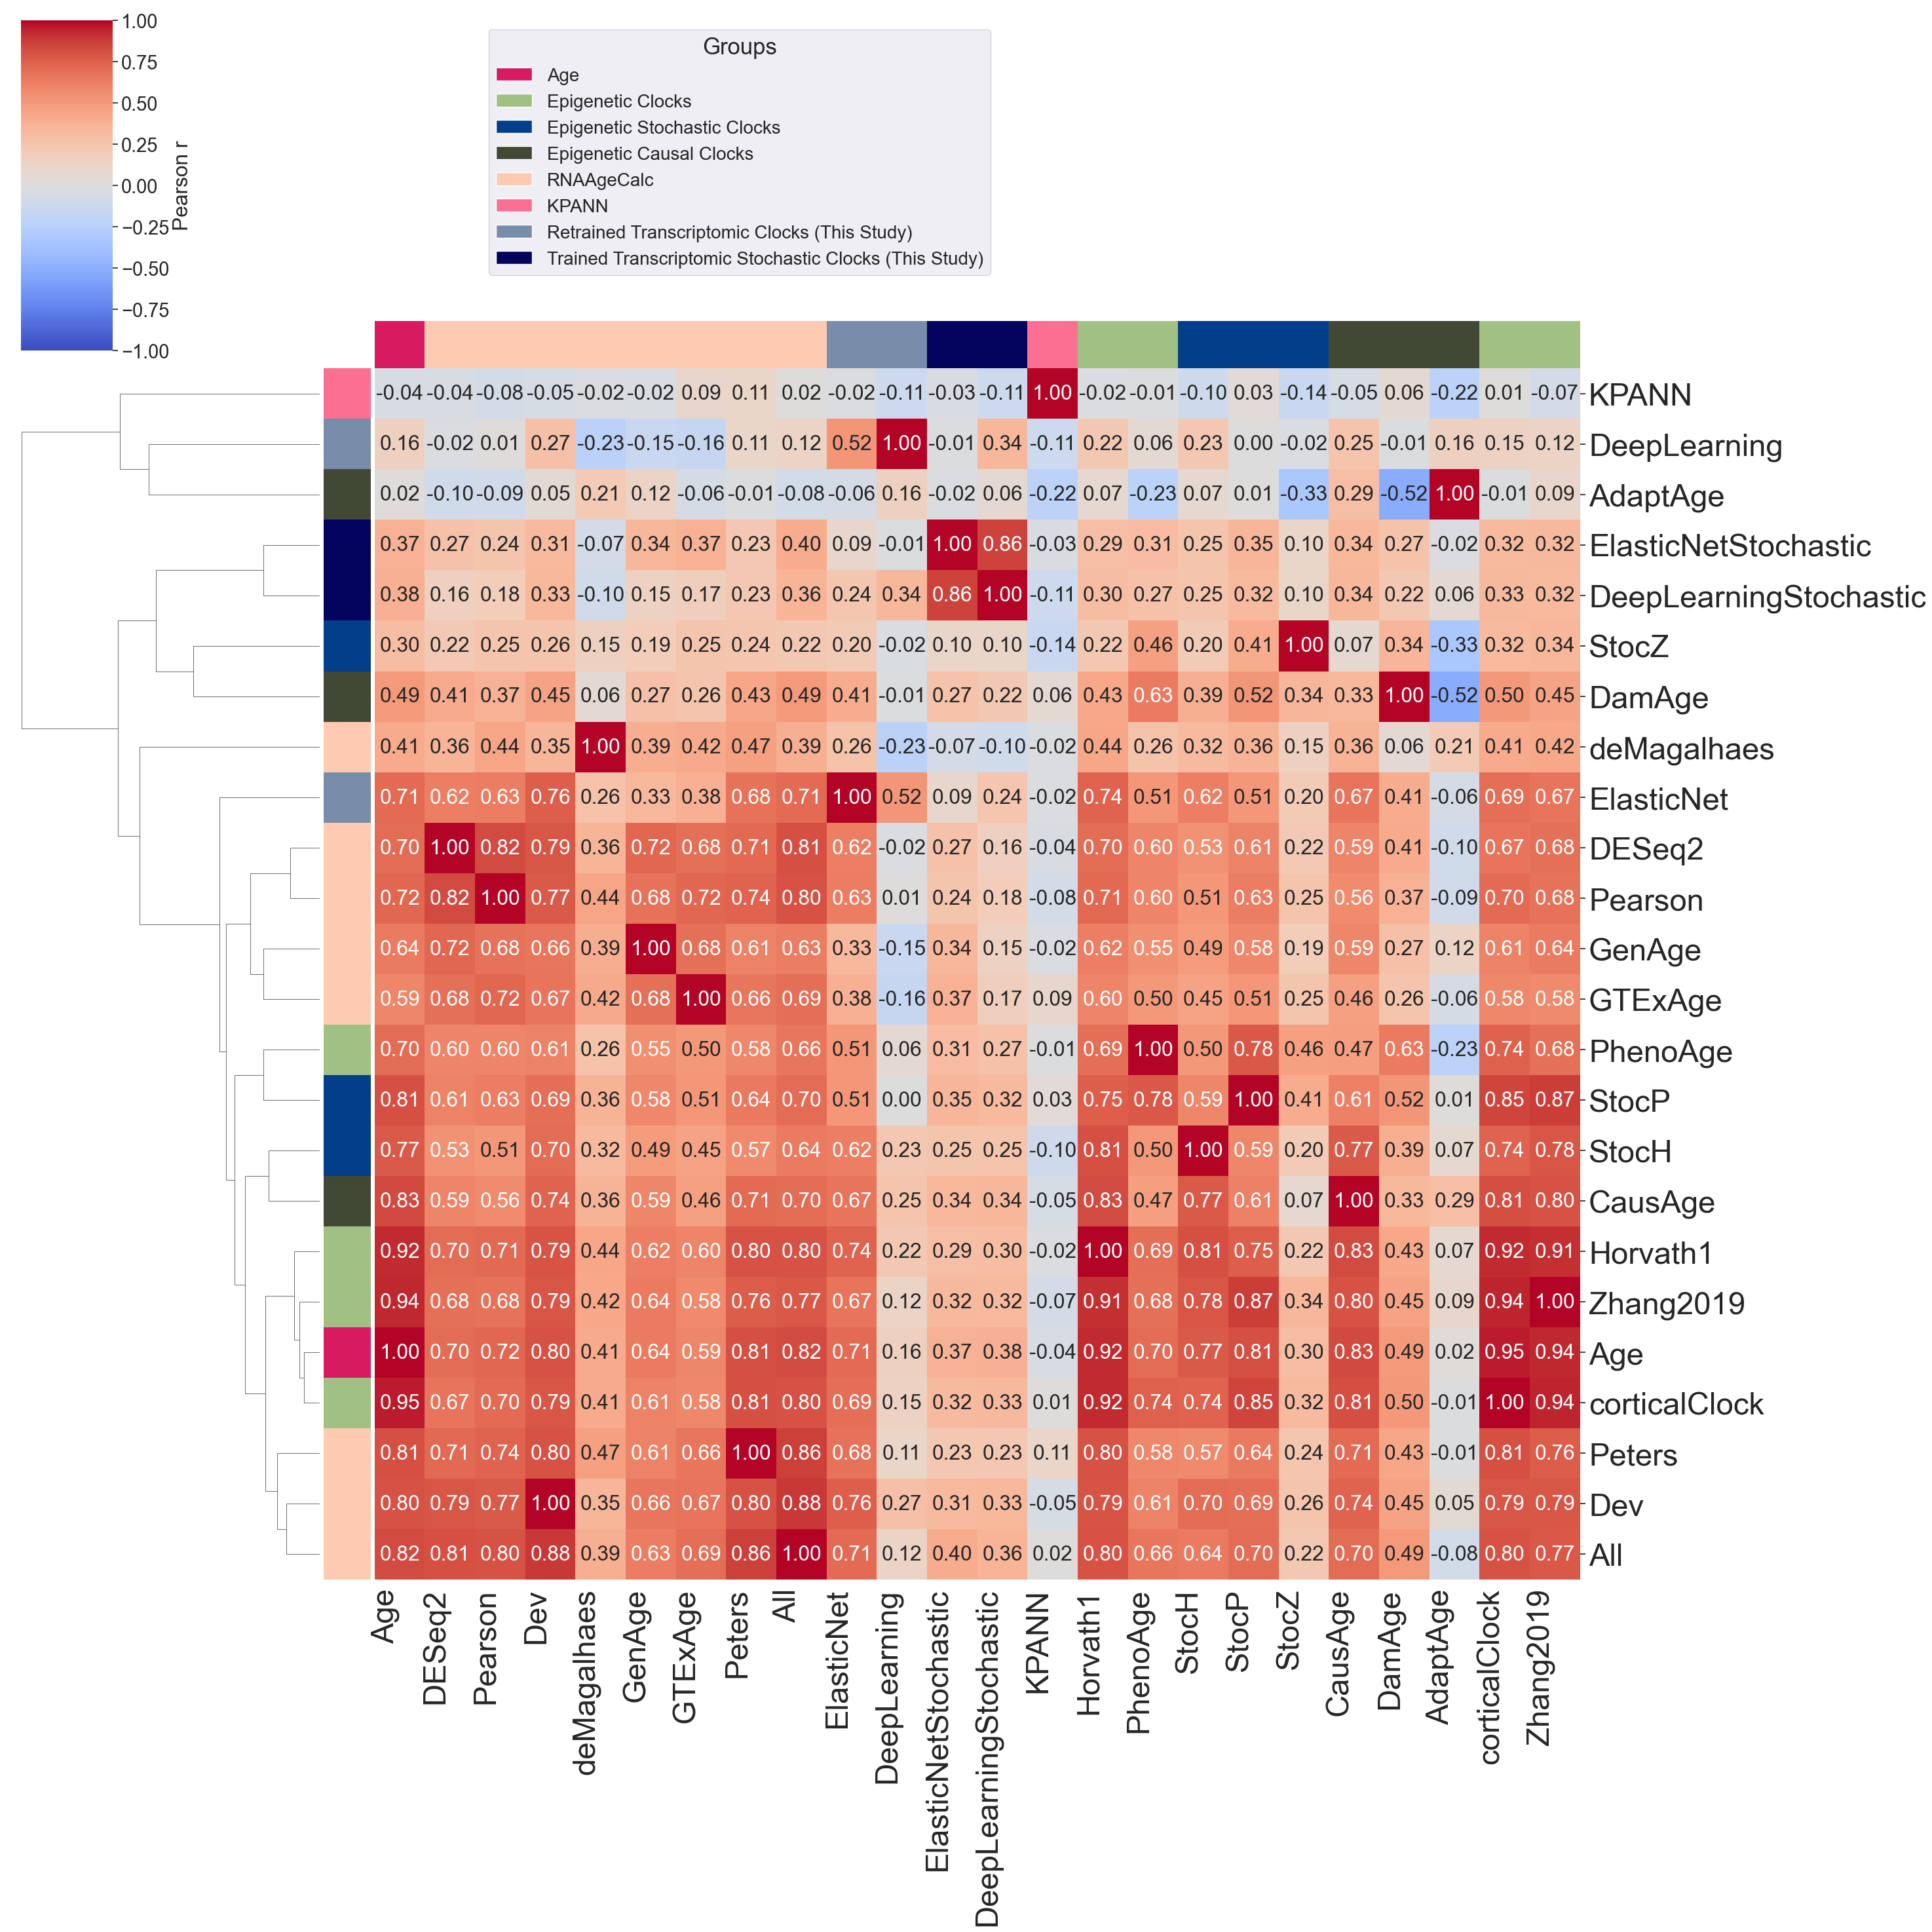

In [33]:
# ------------------------------
# Compute correlation matrix
# ------------------------------
numeric_df = merged_clean_df.select_dtypes(include=['number']).copy()
cols = numeric_df.columns.tolist()
if 'Age' in cols:
    cols.remove('Age')
    cols = ['Age'] + cols
numeric_df = numeric_df[cols]

corr_matrix = numeric_df.corr()

# Clean labels
clean_labels = [col.replace("Predicted_", "").replace("_", " ") for col in corr_matrix.columns]
corr_matrix.columns = clean_labels
corr_matrix.index = clean_labels

# ------------------------------
# Define groups manually
# ------------------------------
age_vars = ["Age"]  # only Age
epigenetic_vars = ["Horvath1", "PhenoAge", "Zhang2019", "corticalClock"]  # <-- add yours here
epigenetic_sto_vars = ["StocH", "StocP", "StocZ"]  # <-- add yours here
epigenetic_cau_vars = ["CausAge", "DamAge", "AdaptAge"]  # <-- add yours here
transcriptomic_vars = ["GTExAge", "DESeq2", "Pearson", "Dev", "deMagalhaes", "GenAge", "GTExAge", "Peters", "All"] # <-- add yours here
transcriptomic_dep_vars = ["KPANN"] # <-- add yours here
transcriptomic_thi_vars = ["ElasticNet", "DeepLearning"] # <-- add yours here
transcriptomic_sto_vars = ["ElasticNetStochastic", "DeepLearningStochastic"] # <-- add yours here

# Assign colors
group_colors = {}
for col in clean_labels:
    if col in age_vars:
        group_colors[col] = "#D81B60"
    elif col in epigenetic_vars:
        group_colors[col] = "#A1C084"
    elif col in epigenetic_sto_vars:
        group_colors[col] = "#023e8a"
    elif col in epigenetic_cau_vars:
        group_colors[col] = "#414833"
    elif col in transcriptomic_vars:
        group_colors[col] = "#FFCAB1"
    elif col in transcriptomic_dep_vars:
        group_colors[col] = "#fb6f92"
    elif col in transcriptomic_thi_vars:
        group_colors[col] = "#778da9"
    elif col in transcriptomic_sto_vars:
        group_colors[col] = "#03045e"
    else:
        group_colors[col] = "gray"  # fallback if something is unassigned

row_colors = [group_colors[label] for label in clean_labels]
col_colors = [group_colors[label] for label in clean_labels]

# ------------------------------
# Plot clustermap
# ------------------------------
sns.set(font_scale=1.9)

cg = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    figsize=(28, 28),
    row_cluster=True,
    col_cluster=False,
    dendrogram_ratio=(0.2, 0.2),
    cbar_kws={"label": "Pearson r"},
    row_colors=row_colors,
    col_colors=col_colors
)

# Axis label font sizes
cg.ax_heatmap.set_xticklabels(cg.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=34)
cg.ax_heatmap.set_yticklabels(cg.ax_heatmap.get_yticklabels(), fontsize=34)

# Legend for group colors
legend_patches = [
    Patch(facecolor="#D81B60", label="Age"),
    Patch(facecolor="#A1C084", label="Epigenetic Clocks"),
    Patch(facecolor="#023e8a", label="Epigenetic Stochastic Clocks"),
    Patch(facecolor="#414833", label="Epigenetic Causal Clocks"),
    Patch(facecolor="#FFCAB1", label="RNAAgeCalc"),
    Patch(facecolor="#fb6f92", label="KPANN"),
    Patch(facecolor="#778da9", label="Retrained Transcriptomic Clocks (This Study)"),
    Patch(facecolor="#03045e", label="Trained Transcriptomic Stochastic Clocks (This Study)")
]
plt.legend(handles=legend_patches, title="Groups", bbox_to_anchor=(5.0, 1.0), loc='upper left', fontsize=20, title_fontsize=25)

# Save
cg.savefig("00clustermap_correlation.pdf", dpi=600, bbox_inches='tight')
plt.show()